## **LOAD LIBRARIES & DATASET**

### Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### Dataset

Download from https://www.kaggle.com/datasets/canggih/jog-description-and-salary-in-indonesia

In [2]:
salarydf = pd.read_csv("all.csv", sep='|')
salarydf.head(5)

,id,job_title,location,salary_currency,career_level,experience_level,education_level,employment_type,job_function,job_benefits,company_process_time,company_size,company_industry,job_description,salary
0,1,Facility Maintenance & Smart Warehouse Manager,Bandung,IDR,Manajer/Asisten Manajer,5 tahun,"Sertifikat Professional, D3 (Diploma), D4 (Dip...",Penuh Waktu,"Manufaktur,Pemeliharaan",NaN,NaN,NaN,NaN,Deskripsi PekerjaanRequirements :D3/SI from re...,NaN
1,2,Procurement Department Head,Jakarta Raya,IDR,Manajer/Asisten Manajer,5 tahun,"Sarjana (S1), Diploma Pascasarjana, Gelar Prof...",Penuh Waktu,"Manufaktur,Pembelian/Manajemen Material",NaN,25 days,51 - 200 pekerja,Manajemen/Konsulting HR,Job Role: 1. Responsible for material availabi...,NaN
2,3,SALES ADMIN,Jakarta Barat,IDR,Supervisor/Koordinator,4 tahun,Sarjana (S1),Penuh Waktu,"Penjualan / Pemasaran,Penjualan Ritel","Waktu regular, Senin - Jumat;Bisnis (contoh: K...",30 days,51 - 200 pekerja,Umum & Grosir,Internal Sales & AdminJob Description :We are ...,NaN
3,4,City Operation Lead Shopee Express (Cirebon),Cirebon,IDR,Supervisor/Koordinator,5 tahun,"Sarjana (S1), Diploma Pascasarjana, Gelar Prof...",Penuh Waktu,"Pelayanan,Logistik/Rantai Pasokan","Tip;Waktu regular, Senin - Jumat;Kasual (conto...",21 days,2001 - 5000 pekerja,Retail/Merchandise,Job Description:Responsible for HSE implementa...,NaN
4,5,Japanese Interpreter,Bekasi,IDR,Pegawai (non-manajemen & non-supervisor),2 tahun,"Sertifikat Professional, D3 (Diploma), D4 (Dip...",Penuh Waktu,"Lainnya,Jurnalis/Editor",NaN,23 days,201 - 500 pekerja,Manajemen/Konsulting HR,Overview: Our clients is manufacture for autom...,NaN


__Meta Data__ :

| Column               | Description                                                                |
| -------------------- | -------------------------------------------------------------------------- |
| `id`                 | Unique identifier for each data record.                                    |
| `job_title`          | Name or title of the job.                                                  |
| `location`           | Location of the company or job.                                            |
| `salary_currency`    | Currency used for the salary.                                              |
| `career_level`       | Career level of the position, such as staff, manager, director, or CEO.    |
| `experience_level`   | Level of work experience required from applicants.                         |
| `education_level`    | Minimum education level required from applicants.                          |
| `employment_type`    | Type of employment, such as full-time, part-time, contract, or internship. |
| `job_function`       | Functional category of the job.                                            |
| `job_benefits`       | Benefits provided by the company.                                          |
| `companyprocesstime` | Average time taken by the company to respond to applicants.                |
| `company_size`       | Number of employees in the company.                                        |
| `company_industry`   | Industry or business sector of the company.                                |
| `job_description`    | Description of the job responsibilities and requirements.                  |
| `salary`             | Monthly salary offered by the company, based on data from March 2022.      |

__Explanation__:

| Section               | Description                                                                                                                                                                                                                                                                                                                                                                                                                      |
| --------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Problem Statement** | Many people want to find jobs based on the offered salary range. In this dataset, each record is classified into one of three salary classes based on the Provincial Minimum Wage or **UMP** of the job location: **Rendah** — salary less than or equal to the province's UMP; **Sedang** — salary greater than the UMP and less than or equal to twice the UMP; and **Tinggi** — salary greater than twice the province's UMP. |
| **Goal**              | Predict the salary class of a job based on its field of work, particularly the `career_level`, `job_function`, and `location` variables.                                                                                                                                                                                                                                                                                         |
| **Target Output**     | Predicted salary-level class: **Rendah**, **Sedang**, or **Tinggi**.                                                                                                                                                                                                                                                                                                                                                             |

## **EDA**

### 1. Dataset Structure

In [3]:
salarydf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34746 entries, 0 to 34745
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    34746 non-null  int64  
 1   job_title             34746 non-null  object 
 2   location              34746 non-null  object 
 3   salary_currency       34742 non-null  object 
 4   career_level          34746 non-null  object 
 5   experience_level      30205 non-null  object 
 6   education_level       34746 non-null  object 
 7   employment_type       33402 non-null  object 
 8   job_function          34746 non-null  object 
 9   job_benefits          27330 non-null  object 
 10  company_process_time  24555 non-null  object 
 11  company_size          29103 non-null  object 
 12  company_industry      33132 non-null  object 
 13  job_description       34745 non-null  object 
 14  salary                9352 non-null   float64
dtypes: float64(1), int6

__Explanation__:
- The dataset consists of 15 variables with 34746 records.
- Variables:
  - `id` has the type of integer.
  - `job_title`, `location`, `salary_currency`, `career_level`, `experience_level`, `education_level`, `employment_type`, `job_function`, `job_benefit`, `company_process_time`, `company_size`, `company_industry`, `job_description` has the type of object.
  - `salary` has the type of float. 
- Some of the variables contain missing values, based on the non-null count.

### 2. Barplots (Target Variable VS Independent Variable)

#### Salary & Career Level

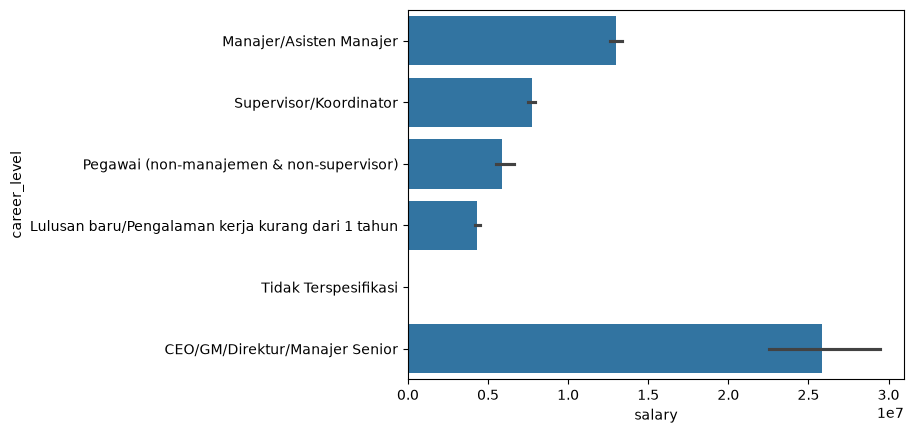

<Figure size 500x300 with 0 Axes>

In [4]:
sns.barplot(data=salarydf, x="salary", y="career_level")
plt.figure(figsize=(5, 3))
plt.show()

__Explanation:__

From the visualization above, the CEO, director, and senior manager receive the highest amount of salary than any other career level. On the other hand, fresh graduates and workers with less than 1 year of working experience have the lowest salary amount.

#### Salary & Experience Level

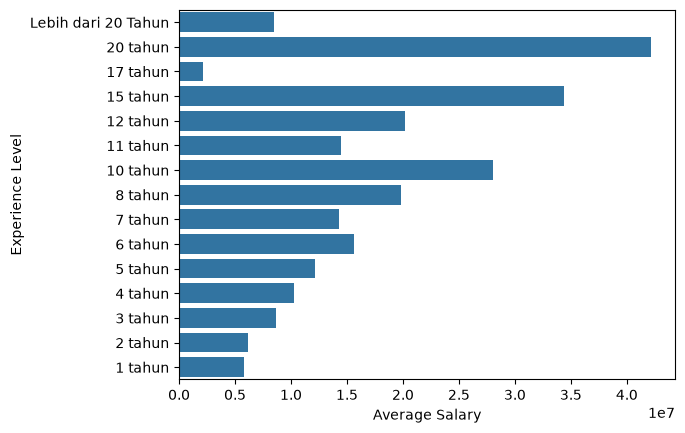

In [5]:
experience_order = ['Lebih dari 20 Tahun','20 tahun','17 tahun','15 tahun','12 tahun','11 tahun','10 tahun','8 tahun',
                    '7 tahun','6 tahun','5 tahun','4 tahun','3 tahun','2 tahun','1 tahun']

sns.barplot(data=salarydf, x="salary", y="experience_level", order=experience_order, errorbar=None)
plt.xlabel("Average Salary")
plt.ylabel("Experience Level")
plt.show()

__Explanation:__

Overall, salary keeps decreasing as the experience level decreased. Except for workers with more than 20 years of job experience, which have lower amount of salary than workers with 20 years experience.

#### Salary & Employment Type

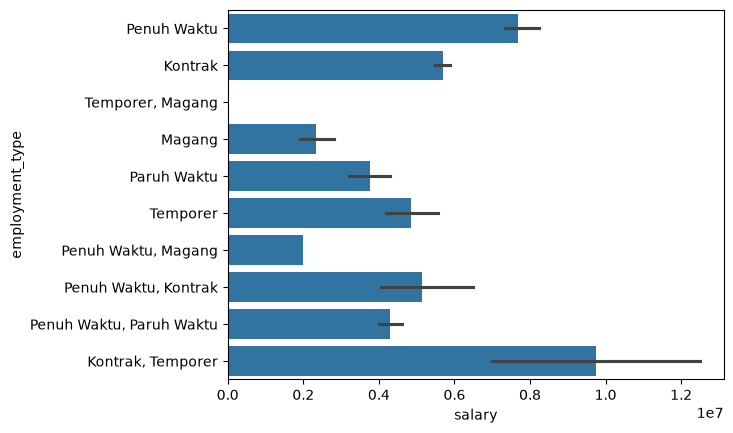

<Figure size 500x300 with 0 Axes>

In [6]:
sns.barplot(data=salarydf, x="salary", y="employment_type")
plt.figure(figsize=(5, 3))
plt.show()

In [7]:
salarydf.groupby(['employment_type'])['salary'].mean()

employment_type
Kontrak                     5.685170e+06
Kontrak, Temporer           9.750000e+06
Magang                      2.337429e+06
Paruh Waktu                 3.755232e+06
Penuh Waktu                 7.686298e+06
Penuh Waktu, Kontrak        5.130429e+06
Penuh Waktu, Magang         2.000000e+06
Penuh Waktu, Paruh Waktu    4.300000e+06
Temporer                    4.850542e+06
Temporer, Magang                     NaN
Name: salary, dtype: float64

__Explanation:__

Based on the table and barplot, full time interns achieve the lowest salary. However, contract workers with temporary jobs suprisingly achieve the highest salary.

#### Salary & Company Process Time

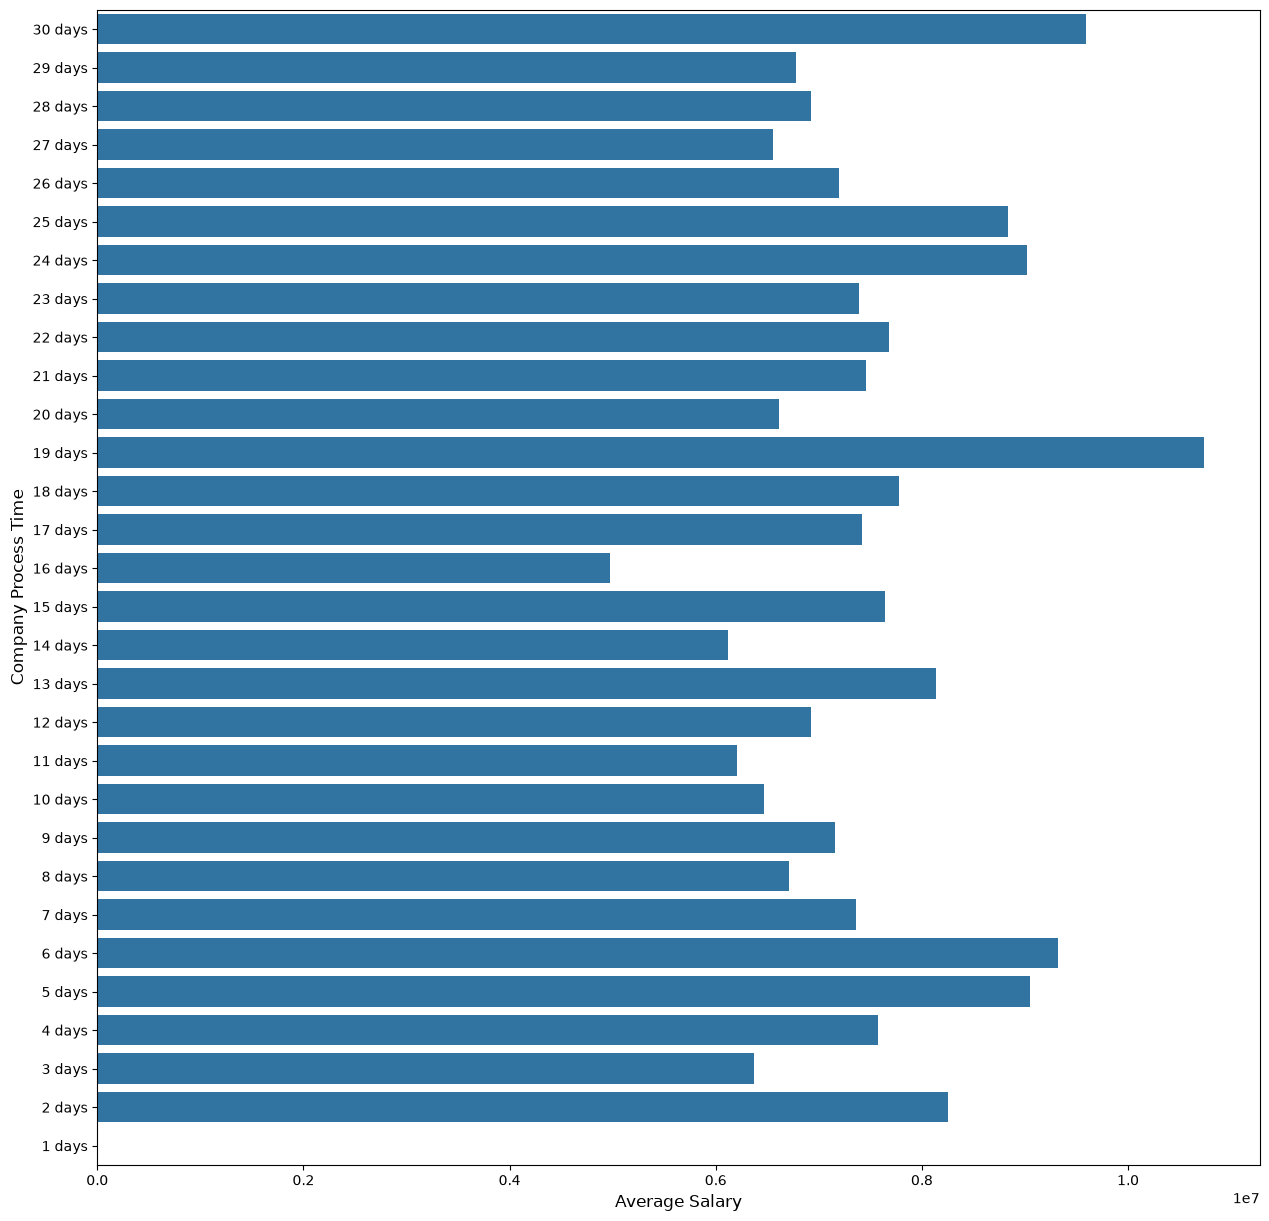

In [8]:
process_time_order = [
    "30 days", "29 days", "28 days", "27 days", "26 days",
    "25 days", "24 days", "23 days", "22 days", "21 days",
    "20 days", "19 days", "18 days", "17 days", "16 days",
    "15 days", "14 days", "13 days", "12 days", "11 days",
    "10 days", "9 days", "8 days", "7 days", "6 days",
    "5 days", "4 days", "3 days", "2 days", "1 days"
]

plt.figure(figsize=(15, 15))

sns.barplot(data=salarydf, x="salary", y="company_process_time", order=process_time_order, errorbar=None)
plt.xlabel("Average Salary", fontsize=12)
plt.ylabel("Company Process Time", fontsize=12)
plt.tick_params(axis="both", which="major", labelsize=10)
plt.show()

__Explanation:__

Overall, there are no visible relation between the amount of salary and how long the companies give responds to applicants.

#### Salary & Company Size

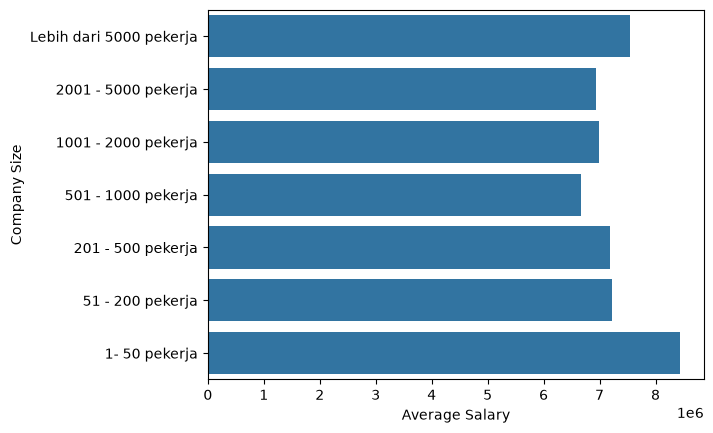

In [9]:
company_size_order = ["Lebih dari 5000 pekerja", "2001 - 5000 pekerja", "1001 - 2000 pekerja", "501 - 1000 pekerja", 
                      "201 - 500 pekerja", "51 - 200 pekerja", "1- 50 pekerja"]

sns.barplot(data=salarydf, x="salary", y="company_size", order=company_size_order, errorbar=None)
plt.xlabel("Average Salary")
plt.ylabel("Company Size")
plt.show()

__Explanation:__

From the barplot above, startups (companies that only have 1-50 workers) give the highest salary, and the medium-sized companies (companies that have 501-1000 workers) give the lowest salary. No visible correlation between the amount of salary vs company size

#### Salary & Company Industry

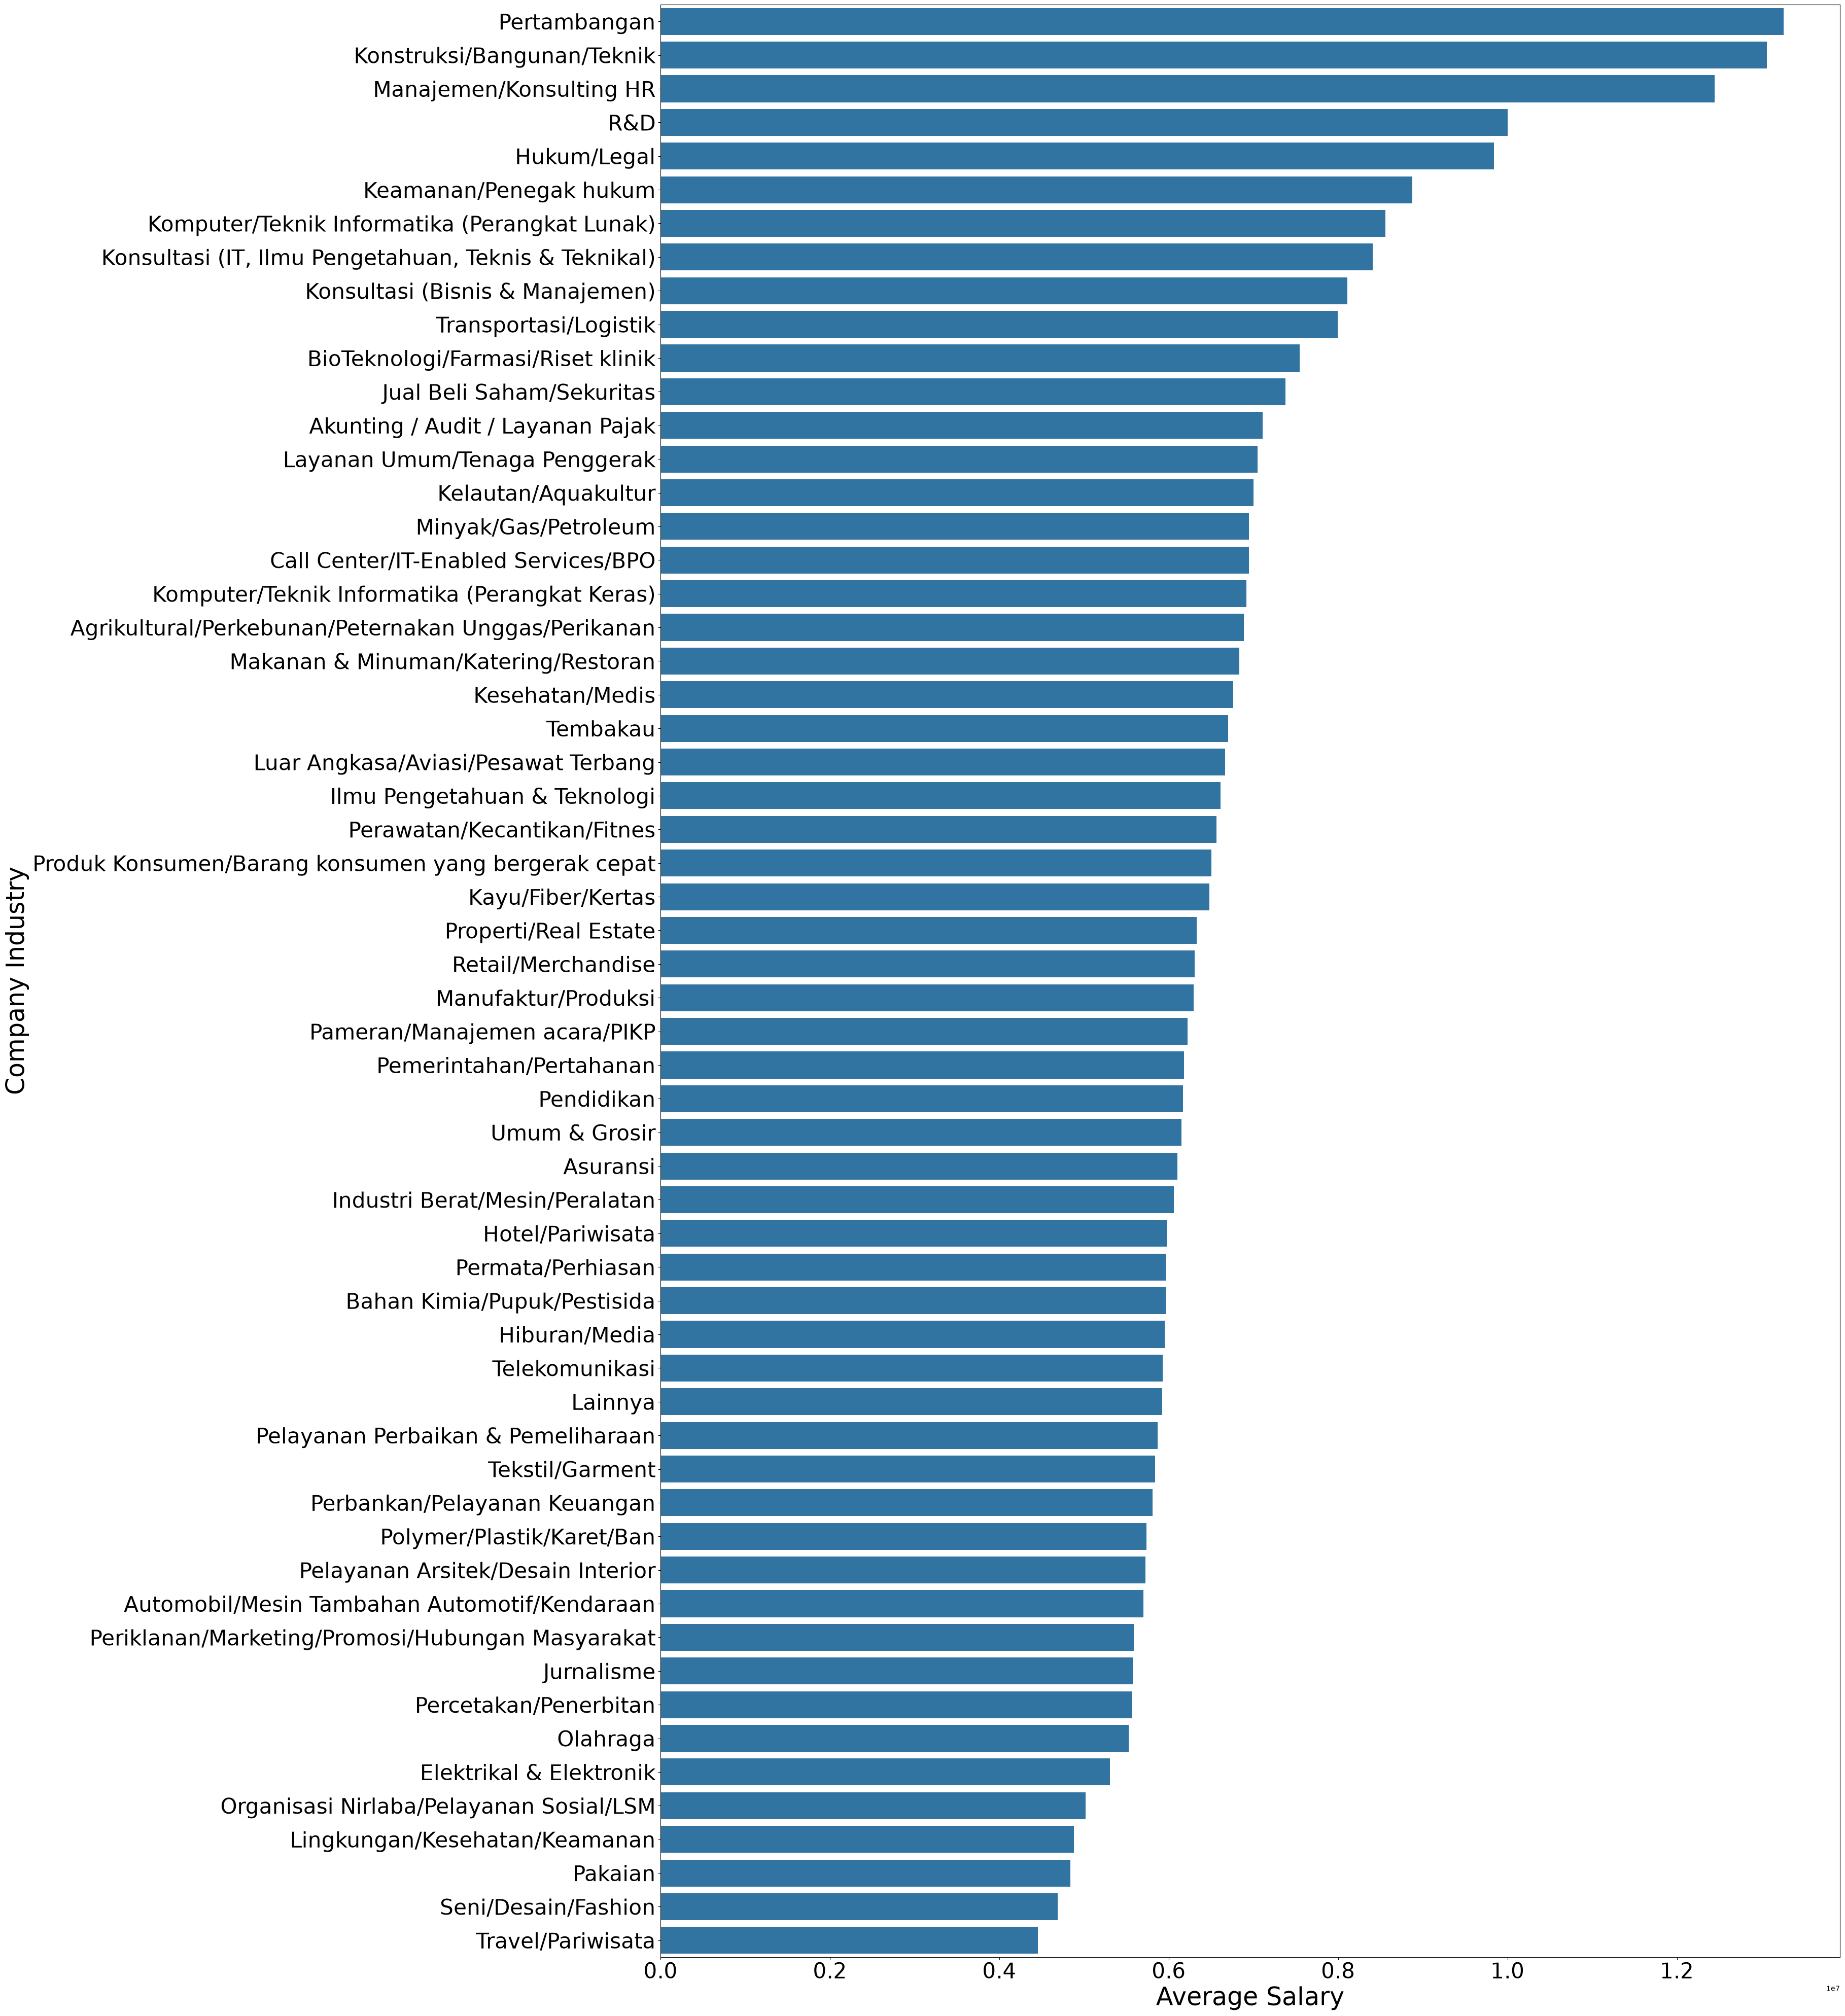

In [10]:
industry_order = (salarydf.groupby("company_industry")["salary"].mean().sort_values(ascending=False).index)

plt.figure(figsize=(30, 50))
sns.barplot(data=salarydf, x="salary", y="company_industry", order=industry_order, errorbar=None)
plt.xlabel("Average Salary", fontsize=35)
plt.ylabel("Company Industry", fontsize=35)
plt.tick_params(axis="both", which="major", labelsize=30)
plt.show()

__Explanation:__

Mining industries and Construction building/engineering industries tend to give the highest salary. On the other hand, tourism industry gives the least salary.

#### Initial Conclusion

In [11]:
salarydf['salary_currency'].value_counts()

salary_currency
IDR    34731
USD       11
Name: count, dtype: int64

__Explanation:__

***From these 6 visualizations, some results appear inconsistent, such as temporary workers and small companies having unusually high average salaries compared to workers with > 20 years job experienc and the big companies. This may be caused by mixed currencies, small category sizes, or salary outliers. Therefore, we need to perform Data Preparation first to standardize the currency and clean the data before drawing conclusions.***

### 3. Check categorical variables related to job titles

In [12]:
job_title_count = pd.DataFrame(salarydf['job_title'].unique())
job_title_count

,0
0,Facility Maintenance & Smart Warehouse Manager
1,Procurement Department Head
2,SALES ADMIN
3,City Operation Lead Shopee Express (Cirebon)
4,Japanese Interpreter
...,...
20627,SOCIAL MEDIA STAFF
20628,Head Of Subdivision (English Speaking) Bandung
20629,Receiving Staff
20630,Operator CNC Milling


In [13]:
salarydf['career_level'].unique()

array(['Manajer/Asisten Manajer', 'Supervisor/Koordinator',
       'Pegawai (non-manajemen & non-supervisor)',
       'Lulusan baru/Pengalaman kerja kurang dari 1 tahun',
       'Tidak Terspesifikasi', 'CEO/GM/Direktur/Manajer Senior'],
      dtype=object)

In [14]:
job_func_count = pd.DataFrame(salarydf['job_function'].unique())
job_func_count

,0
0,"Manufaktur,Pemeliharaan"
1,"Manufaktur,Pembelian/Manajemen Material"
2,"Penjualan / Pemasaran,Penjualan Ritel"
3,"Pelayanan,Logistik/Rantai Pasokan"
4,"Lainnya,Jurnalis/Editor"
...,...
63,"Teknik,Minyak/Gas"
64,"Sains,Kimia"
65,"Manufaktur,Kontrol Proses"
66,"Seni/Media/Komunikasi,Hiburan"


__Explanation__:

From the output above, we can see that:
- in `job_title` there are 5899 categories. There are only ~9000 data, so this variable's correlation with the target variable won't be so high due to small samples on each category.
- in `career_level` there are 5 categories.
- in `job_function` there are 67 categories.
- `career_level` and `job_function` would have a better correlation with our target variable than `job_title` since they have less categories in them.